# **FA 590- Statistical Learning in Finance**

# **Assignment 1: Loan Default and Return Prediction using Linear Models**

**Ayush Sandip Parekh**



This codebase is structured and build following the SEMMA framework which entails:

**S**ample: Selecting a relevant subset of data for analysis.

**E**xplore: Understanding the data through visualization and statistical analysis.

**M**odify: Cleaning and transforming the data to prepare it for modeling.

**M**odel: Applying various machine learning algorithms to build predictive models.

**A**ssess: Evaluating the performance of the models and refining them as needed.


#  **S**ample

In [127]:
# Loading the dataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

Dropping the 'id' Column

The id column is unique to each loan and does not contribute to predicting returns. Dropping it helps reduce noise.

In [128]:
loan = pd.read_csv("/content/lc_loan.csv")
loan = loan.drop(columns=("id"))
print("Size of Dataset : " + str(loan.shape))

Size of Dataset : (933160, 36)


#  **E**xplore

Checking Missing Values and Dataset Overview

Using loan.info() and loan.isnull().sum() helps identify missing values and understand the dataset structure, which is crucial before feature engineering.


In [129]:
loan.info()

loan.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933160 entries, 0 to 933159
Data columns (total 36 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   933160 non-null  float64
 1   funded_amnt                 933160 non-null  float64
 2   int_rate                    933160 non-null  float64
 3   installment                 933160 non-null  float64
 4   grade                       933160 non-null  object 
 5   sub_grade                   933160 non-null  object 
 6   emp_length                  874392 non-null  object 
 7   home_ownership              933160 non-null  object 
 8   annual_inc                  933160 non-null  float64
 9   verification_status         933160 non-null  object 
 10  issue_d                     933160 non-null  object 
 11  loan_status                 933160 non-null  object 
 12  purpose                     933160 non-null  object 
 13  zip_code      

,0
loan_amnt,0
funded_amnt,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,58768
home_ownership,0
annual_inc,0
verification_status,0


In [130]:
key_variables = loan[['loan_amnt','int_rate','installment','emp_length','annual_inc','dti','fico_range_low','fico_range_high','revol_bal','revol_util','total_acc','return']]
key_variables.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,revol_bal,revol_util,total_acc,return
count,933160.000000,933160.000000,933160.000000,9.331600e+05,933160.000000,933160.000000,933160.000000,9.331600e+05,933160.000000,933160.000000,933160.000000
mean,12559.115559,0.119775,416.318741,7.412200e+04,17.833822,695.139858,699.139987,1.565339e+04,0.523420,24.273673,0.065197
std,8042.750083,0.039952,268.816718,6.938399e+04,8.377159,31.359123,31.359739,2.242787e+04,0.240878,11.821678,0.247727
min,500.000000,0.053200,14.010000,3.000000e+03,-1.000000,660.000000,664.000000,0.000000e+00,0.000000,2.000000,-1.000000
25%,6425.000000,0.089000,215.630000,4.400000e+04,11.520000,670.000000,674.000000,5.705000e+03,0.344000,16.000000,0.073529
50%,10000.000000,0.115300,339.310000,6.200000e+04,17.280000,690.000000,694.000000,1.049600e+04,0.526000,23.000000,0.127677
75%,16275.000000,0.143300,549.940000,9.000000e+04,23.700000,710.000000,714.000000,1.865600e+04,0.708000,31.000000,0.188737
max,40000.000000,0.309900,1584.900000,9.573072e+06,49.960000,845.000000,850.000000,2.904836e+06,8.923000,176.000000,0.581820


**Histogram**

Creating histograms to visualize the distribution of the selected numeric variables

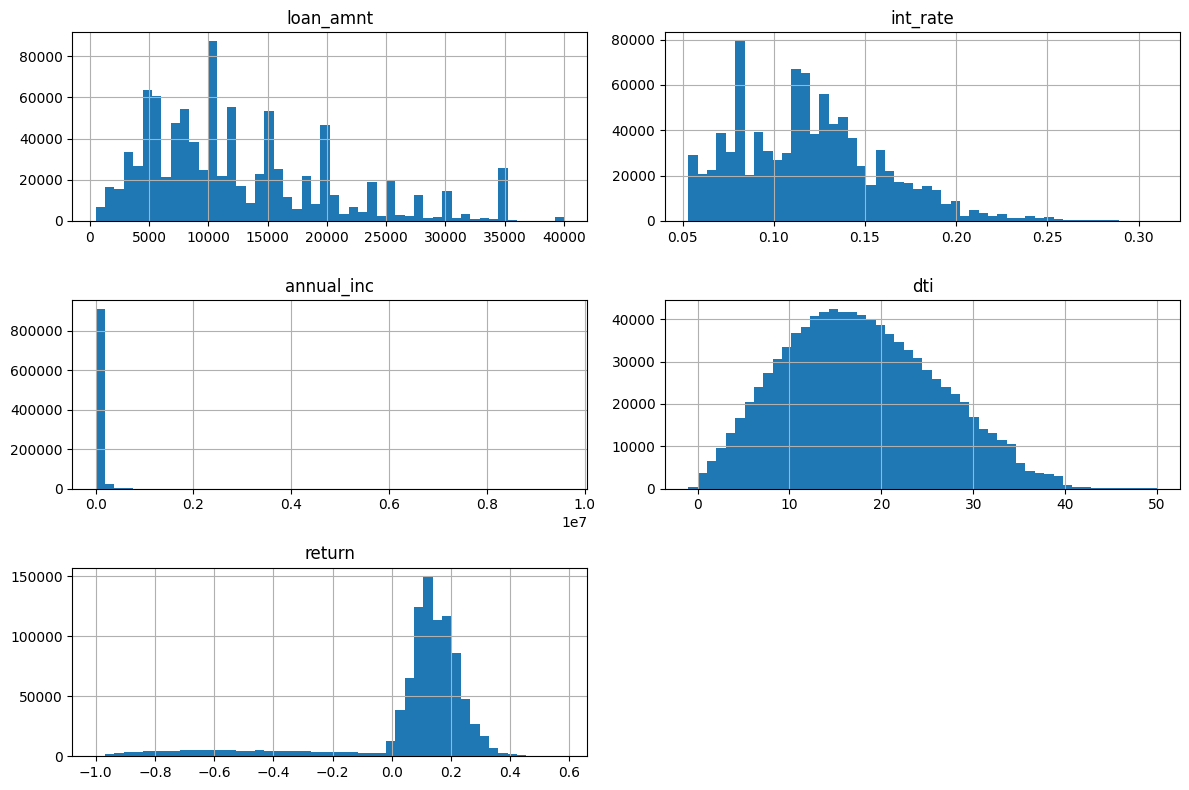

In [131]:
loan[['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'return']].hist(bins=50, figsize=(12,8))
plt.tight_layout()
plt.show()

**1. Loan Amount (loan_amnt)**

The distribution is right-skewed, with most loans concentrated below $20,000.
There are visible peaks at common loan values, likely due to standard loan offerings.

**2. Interest Rate (int_rate)**

The distribution is right-skewed, with most interest rates ranging between 5% and 20%.
There are multiple spikes, possibly reflecting credit score tiers or loan risk categories.

**3. Annual Income (annual_inc)**

The distribution is highly right-skewed, with most borrowers having relatively low annual incomes.
There are extreme outliers with very high incomes, which may require further investigation for data quality issues.

**4. Debt-to-Income Ratio (dti)**

This follows a bell-shaped distribution, peaking around 15-20.
The range extends up to 50, indicating some borrowers have very high debt burdens relative to income.

**5. Return (return)**

The return distribution is slightly skewed left but mostly centered around 0-0.2.
There are negative returns, suggesting some loans resulted in losses.

**Heat Map**

The heatmap is a clear and visually intuitive way to display how variables are correlated with each other, making it easier to identify strong positive or negative relationships.

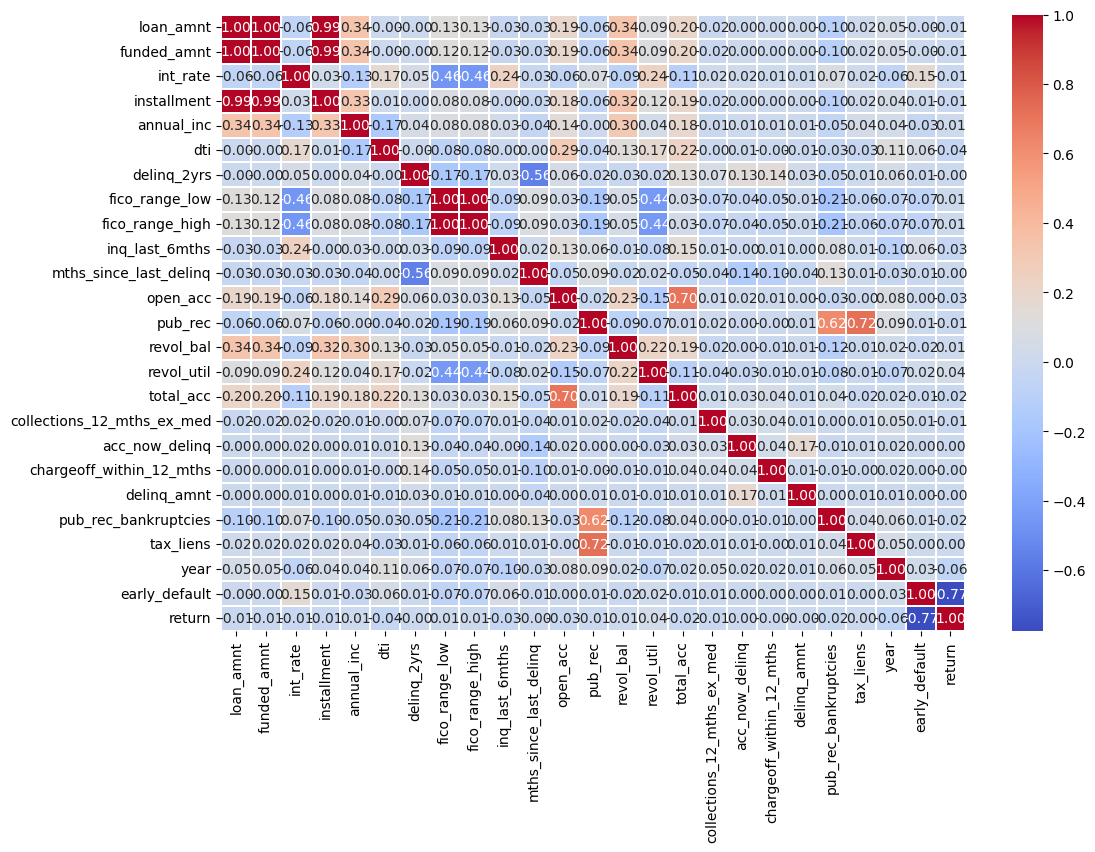

In [132]:
numeric_loan = loan.select_dtypes(include=[np.number])
corr_matrix = numeric_loan.corr()

# Ploting heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.2)
plt.show()

**Highly Correlated Variables:**

Loan amount and funded amount have a near-perfect correlation (1.00), which is expected as they represent similar financial figures.
Installment is highly correlated with loan amount (0.99), indicating that larger loans come with higher installments.
FICO range low and FICO range high also have a strong correlation (~0.46), which is logical since they represent different ends of the same credit score range.

**Negative Correlations:**

FICO range low and revol_util (~ -0.44) suggest that lower FICO scores are associated with higher revolving credit utilization.
Dti (debt-to-income ratio) has weak correlations with most variables, but its impact on return is slightly negative.

**Return Correlation:**

The correlation between return and most variables is weak, indicating that no single factor strongly determines returns.
Early default has a slight positive correlation (~0.77), which makes sense as defaults impact returns.

# **M**odify

Dropping 'mths_since_last_delinq'

This variable has a high percentage of missing values (around 50%), making it unreliable for prediction. Dropping it prevents potential biases.

In [133]:
loan = loan.drop(columns=['mths_since_last_delinq'])

**Encoding 'emp_length'**
*   The employment length is converted into numerical values because ML models work better with numbers.
*   "< 1 year" is set to 0, "10+ years" is set to 10, and other values are converted accordingly.
*   Missing values are filled with the median since employment length likely follows a skewed distribution.














In [134]:
def convert_emp_length(emp):
    if pd.isnull(emp) or emp == 'n/a':
        return np.nan
    elif '<' in str(emp):
        return 0
    elif '+' in str(emp):
        return 10
    else:
        return int(str(emp).split()[0])
loan['emp_length'] = loan['emp_length'].apply(convert_emp_length)

In [135]:
loan['emp_length'] = loan['emp_length'].fillna(loan['emp_length'].median())

**Encoding Loan Grades**
*  'grade' and 'sub_grade' indicate creditworthiness.
*   Higher grades (A, B) correspond to lower risks, so they are mapped to higher numerical values.
*   'sub_grade' is more granular, providing finer credit risk differentiation, which could help predict returns more accurately.

In [136]:
grade_mapping = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
loan['grade'] = loan['grade'].map(grade_mapping)

In [137]:
sub_grade_mapping = {
    'A1': 35, 'A2': 34, 'A3': 33, 'A4': 32, 'A5': 31,
    'B1': 30, 'B2': 29, 'B3': 28, 'B4': 27, 'B5': 26,
    'C1': 25, 'C2': 24, 'C3': 23, 'C4': 22, 'C5': 21,
    'D1': 20, 'D2': 19, 'D3': 18, 'D4': 17, 'D5': 16,
    'E1': 15, 'E2': 14, 'E3': 13, 'E4': 12, 'E5': 11,
    'F1': 10, 'F2': 9, 'F3': 8, 'F4': 7, 'F5': 6,
    'G1': 5, 'G2': 4, 'G3': 3, 'G4': 2, 'G5': 1
}
loan['sub_grade'] = loan['sub_grade'].map(sub_grade_mapping)

Calculating 'fico_score_avg'

FICO scores indicate credit risk. Using the average of fico_range_low and fico_range_high provides a single, representative metric.

The original FICO range columns are dropped to avoid redundancy.

In [138]:
loan['fico_score_avg'] = (loan['fico_range_low'] + loan['fico_range_high']) / 2
loan.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

Creating 'loan_burden'

installment / (annual_inc / 12) measures how much of a borrower's monthly income goes toward loan repayment.

A high loan burden suggests a higher risk of default, which impacts returns.

In [139]:
loan['loan_burden'] = loan['installment'] / (loan['annual_inc'] / 12)

In [140]:
correlation = loan[['loan_burden', 'return']].corr()
print(correlation)

             loan_burden    return
loan_burden     1.000000 -0.036719
return         -0.036719  1.000000


**Transforming Income and Installment (Log Transformation)**

log_annual_inc and log_installment are used instead of raw values to reduce skewness, which improves model performance.

High-income borrowers may have different return patterns, so normalizing this feature helps capture non-linear effects.


In [141]:
loan['log_annual_inc'] = np.log1p(loan['annual_inc'])
loan['log_installment'] = np.log1p(loan['installment'])
loan.drop(columns=['annual_inc','installment'], inplace=True)

**Creating Interaction Features**

*   loan_int_rate = loan_amnt * int_rate → Captures the combined effect
of loan size and interest rate on returns.
*   fico_revol_util = fico_score_avg * revol_util → Measures how a borrower’s credit score interacts with revolving credit utilization
*   dti_income = dti * log_annual_inc → Adjusts debt-to-income ratio by incorporating income distribution.
*   int_rate_squared = int_rate ** 2 → Captures non-linear relationships where extremely high/low interest rates might impact returns differently.
*  Scaling 'loan_amnt', 'revol_bal', and 'total_acc'

    Standardizing ensures these variables are on the same scale, preventing certain large-value features from dominating the model.

In [142]:
loan['loan_int_rate'] = loan['loan_amnt'] * loan['int_rate']
loan['fico_revol_util'] = loan['fico_score_avg'] * loan['revol_util']
loan['dti_income'] = loan['dti'] * loan['log_annual_inc']
loan['int_rate_squared'] = loan['int_rate'] ** 2

In [143]:
scaler = StandardScaler()
loan[['loan_amnt', 'revol_bal', 'total_acc']] = scaler.fit_transform(loan[['loan_amnt', 'revol_bal', 'total_acc']])

**Compute Credit History Length**

The earliest credit line (earliest_cr_line) contains date information in a month-year format (e.g., "Jan-10"). Now converting these dates into a full date format (MM/DD/YYYY), where the month abbreviation is mapped to its numerical representation.

The **credit history length** is calculated by subtracting the year of the earliest credit line from the current year. This gives the number of years the person has had credit, which is an important feature for predicting loan returns. A longer credit history often correlates with better creditworthiness and loan repayment potential.

In [144]:
from datetime import datetime

# Function to convert the date
def convert_date(date_string):
    # Mapping of month abbreviations to month numbers
    month_map = {
        'Jan': '01',
        'Feb': '02',
        'Mar': '03',
        'Apr': '04',
        'May': '05',
        'Jun': '06',
        'Jul': '07',
        'Aug': '08',
        'Sep': '09',
        'Oct': '10',
        'Nov': '11',
        'Dec': '12'
    }

    # Spliting the input into month and year
    month, year = date_string.split('-')

    # Handling two-digit years by assuming they are in the 2000s
    if len(year) == 2:
        year = '20' + year

    # Converting to full date format 'MM/DD/YYYY'
    formatted_date = f"{month_map[month]}-01-{year}"

    # Returning the formatted date in MM/DD/YYYY format
    return datetime.strptime(formatted_date, '%m-%d-%Y').strftime('%m/%d/%Y')

loan['earliest_cr_line'] = loan['earliest_cr_line'].apply(convert_date)

In [145]:
loan['earliest_cr_year'] = pd.to_datetime(loan['earliest_cr_line'], format='%d/%m/%Y').dt.year

# Compute credit history length
current_year = datetime.now().year
loan['credit_history_length'] = current_year - loan['earliest_cr_year']

print(loan[['earliest_cr_line', 'credit_history_length']].head())
loan.drop(columns=['earliest_cr_year'], inplace=True)

  earliest_cr_line  credit_history_length
0       01/01/1985                     40
1       11/01/2001                     24
2       02/01/1996                     29
3       11/01/2004                     21
4       01/01/2007                     18


**Dropping Irrelevant or Redundant Columns**

'funded_amnt': This is highly correlated with loan_amnt, making it redundant.

'zip_code' and 'addr_state': These do not provide useful predictive power in numerical models and might introduce unnecessary complexity.

'loan_status' and 'early_default': Loan status directly defines whether a loan is in good standing or defaulted. Since we are predicting returns, this would create data leakage.

'earliest_cr_line': Already converted into credit_history_length, making it unnecessary.

'issue_d' and 'year': These are timestamps related to when the loan was issued and do not contribute meaningfully to predicting returns.

'purpose': Loan purpose is categorical and may not significantly impact returns. Dropping it simplifies the model.

In [146]:
loan.drop(columns=['funded_amnt', 'zip_code','addr_state','loan_status','early_default','earliest_cr_line', 'issue_d','year','delinq_amnt','tax_liens','purpose'], inplace=True)

Additional Weakly Relevant Features

Has very low correlation with return, meaning it likely does not contribute meaningfully to the model.

In [147]:
loan.drop(columns=['delinq_2yrs', 'chargeoff_within_12_mths'], inplace=True)

**Splitting Data into Training and Validation Sets**

In [148]:
X = loan.drop(columns=['return'])
y = loan['return']

In [149]:
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.3, random_state=42)

In [150]:
train_X.reset_index(drop=True, inplace=True)
val_X.reset_index(drop=True, inplace=True)
train_y.reset_index(drop=True, inplace=True)
val_y.reset_index(drop=True, inplace=True)

**Encoding Categorical Variables**

One-Hot Encoding: Converts categorical variables (home_ownership, verification_status) into numerical form so the model can process them.

Using drop_first=True: Drops the first category to avoid the dummy variable trap, preventing multicollinearity.

In [151]:
train_X = pd.get_dummies(train_X, columns=['home_ownership', 'verification_status'], drop_first=True)
val_X = pd.get_dummies(val_X, columns=['home_ownership', 'verification_status'], drop_first=True)

In [152]:
val_X = val_X.reindex(columns=train_X.columns, fill_value=0)

Calculating the correlation of all independent variables with 'return'

In [153]:
train_data = pd.concat([train_X, train_y], axis=1)

correlation = train_data.corr()['return'].sort_values(ascending=False)

print("Correlation of all variables with returns:")
print(correlation)

Correlation of all variables with returns:
return                                 1.000000
fico_revol_util                        0.038827
revol_util                             0.036789
home_ownership_MORTGAGE                0.030817
grade                                  0.023519
credit_history_length                  0.023274
sub_grade                              0.022862
log_annual_inc                         0.020755
emp_length                             0.014640
revol_bal                              0.013965
fico_score_avg                         0.007620
home_ownership_NONE                    0.001062
acc_now_delinq                         0.000455
home_ownership_OTHER                  -0.000678
home_ownership_OWN                    -0.005786
collections_12_mths_ex_med            -0.007311
loan_amnt                             -0.009141
verification_status_Source Verified   -0.011105
pub_rec                               -0.011121
int_rate                              -0.0120

<ipython-input-154-cb11ea2cc143>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.index, y=correlation.values, palette="coolwarm", hue=None, legend=False)


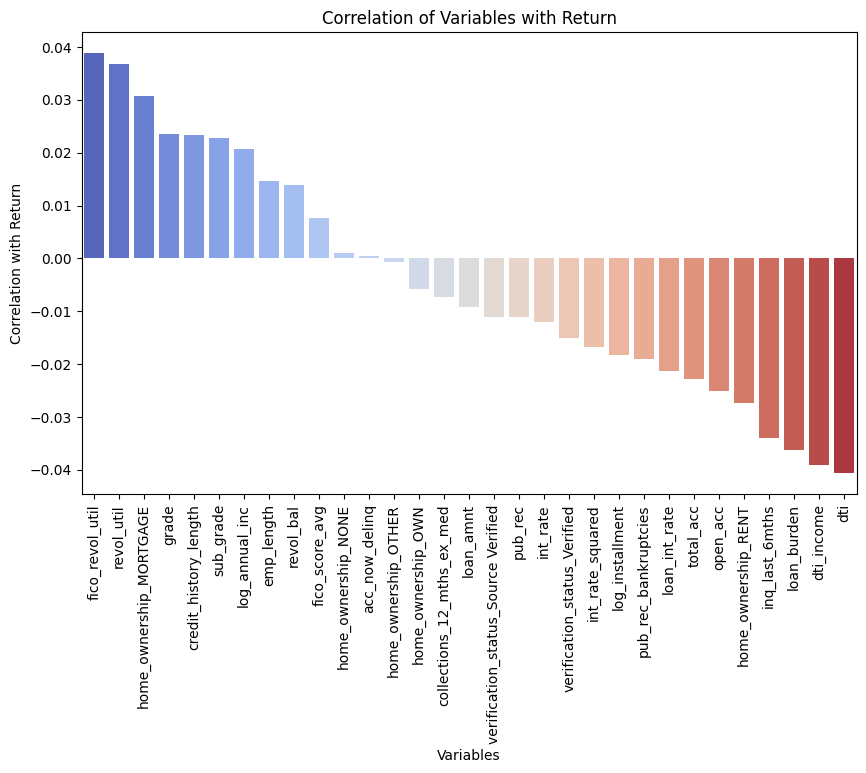

In [154]:
correlation = correlation.drop('return')
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation.index, y=correlation.values, palette="coolwarm", hue=None, legend=False)
plt.xticks(rotation=90)
plt.xlabel("Variables")
plt.ylabel("Correlation with Return")
plt.title("Correlation of Variables with Return")
plt.show()

**Positive Correlations:**

Variables like fico_revol_util, and credit_history_length have a slight positive correlation with returns, meaning higher values in these features are associated with slightly better loan returns.

**Negative Correlations:**

Features such as dti_income, loan_burden, and home_ownership_RENT show a negative correlation with returns. This suggests that higher debt-to-income ratios and heavier loan burdens are associated with lower returns.

**Magnitude:**

The correlations are generally weak, indicating that no single factor strongly determines loan returns. However, debt-related variables tend to have a more negative impact compared to other factors.

# **M**odel

**Linear Regression (Baseline Model)**

The model is tested on both the training and validation datasets to compute the R-squared (R²), a metric that indicates how well the model explains the variance of the target variable.

In [155]:
from sklearn.metrics import r2_score

lin_reg = LinearRegression()
lin_reg.fit(train_X, train_y)

train_y_pred = lin_reg.predict(train_X)
val_y_pred = lin_reg.predict(val_X)

r2_train = r2_score(train_y, train_y_pred)
r2_val = r2_score(val_y, val_y_pred)

print(f"Simple Linear Regression - R² (Train): {r2_train:.4f}")
print(f"Simple Linear Regression - R² (Validation): {r2_val:.4f}")

Simple Linear Regression - R² (Train): 0.0121
Simple Linear Regression - R² (Validation): 0.0118


**Ridge Regression (Regularized Linear Model)**

The performance of the Ridge Regression model is evaluated using R² on both the training and validation sets.

In [156]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

In [157]:
alphas = [0.1, 0.05, 0.01, 0.005, 0.001]

In [158]:
ridge = GridSearchCV(Ridge(), param_grid={'alpha': alphas}, cv=5, scoring='r2')
ridge.fit(train_X, train_y)
ridge_best = ridge.best_estimator_
ridge_r2_train = r2_score(train_y, ridge_best.predict(train_X))
ridge_r2_val = r2_score(val_y, ridge_best.predict(val_X))
print(f"Ridge Regression - Best Alpha: {ridge.best_params_['alpha']}")
print(f"Ridge Regression - R² (Train): {ridge_r2_train:.4f}, R² (Validation): {ridge_r2_val:.4f}")

Ridge Regression - Best Alpha: 0.01
Ridge Regression - R² (Train): 0.0121, R² (Validation): 0.0118


**Lasso Regression (Regularized Linear Model with Feature Selection)**



In [159]:
alpha_lasso = 0.01

lasso = Lasso(alpha=alpha_lasso)
lasso.fit(train_X, train_y)

lasso_train_pred = lasso.predict(train_X)
lasso_val_pred = lasso.predict(val_X)

lasso_r2_train = r2_score(train_y, lasso_train_pred)
lasso_r2_val = r2_score(val_y, lasso_val_pred)

print(f"Lasso Regression - Alpha: {alpha_lasso}")
print(f"Lasso Regression - R² (Train): {lasso_r2_train:.4f}, R² (Validation): {lasso_r2_val:.4f}")

Lasso Regression - Alpha: 0.01
Lasso Regression - R² (Train): 0.0055, R² (Validation): 0.0051


**Loading the Test Dataset**

The test data is used to evaluate the performance of the model trained on the training set.

In [160]:
# Loading the test dataset
test = pd.read_csv("/content/lc_loan_test.csv")

**Aligning Columns with Training Set**

Ensuring that the test set has the same columns as the training set (including the same number of features and order). This step ensures compatibility with the trained model.

In [161]:
# Droping unnecessary columns (same as training set)
test = test.drop(columns=['id', 'mths_since_last_delinq'])

# Applying transformations from training set
test['emp_length'] = test['emp_length'].apply(convert_emp_length)
test['emp_length'] = test['emp_length'].fillna(loan['emp_length'].median())

# Encoding categorical variables
test['grade'] = test['grade'].map(grade_mapping)
test['sub_grade'] = test['sub_grade'].map(sub_grade_mapping)

# Feature engineering
test['fico_score_avg'] = (test['fico_range_low'] + test['fico_range_high']) / 2
test.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

test['loan_burden'] = test['installment'] / (test['annual_inc'] / 12)
test['log_annual_inc'] = np.log1p(test['annual_inc'])
test['log_installment'] = np.log1p(test['installment'])
test.drop(columns=['annual_inc','installment'], inplace=True)

test['loan_int_rate'] = test['loan_amnt'] * test['int_rate']
test['fico_revol_util'] = test['fico_score_avg'] * test['revol_util']
test['dti_income'] = test['dti'] * test['log_annual_inc']
test['int_rate_squared'] = test['int_rate'] ** 2

test[['loan_amnt', 'revol_bal', 'total_acc']] = scaler.transform(test[['loan_amnt', 'revol_bal', 'total_acc']])

test['earliest_cr_line'] = test['earliest_cr_line'].apply(convert_date)
test['earliest_cr_year'] = pd.to_datetime(test['earliest_cr_line'], format='%d/%m/%Y').dt.year
current_year = datetime.now().year
test['credit_history_length'] = current_year - test['earliest_cr_year']
test.drop(columns=['earliest_cr_year', 'earliest_cr_line'], inplace=True)

test.drop(columns=['funded_amnt', 'zip_code','addr_state','issue_d','year','delinq_amnt','tax_liens','purpose'], inplace=True)
test.drop(columns=['delinq_2yrs', 'chargeoff_within_12_mths'], inplace=True)

test = pd.get_dummies(test, columns=['home_ownership', 'verification_status'], drop_first=True)

test = test.reindex(columns=train_X.columns, fill_value=0)

**Predict with the Model**

The trained Ridge Regression model (the best model found) is used to make predictions on the test data. The predictions are the loan return estimates.

In [162]:
test_predictions = ridge_best.predict(test)

# **A**ssess

In [163]:
submission = pd.read_csv("/content/submission_test.csv")

In [164]:
submission['return'] = test_predictions

In [165]:
submission.to_csv("/content/final_submission.csv", index=False)

In [166]:
print(f"Test dataset shape: {test.shape}")
print(f"Training dataset shape: {train_X.shape}")

Test dataset shape: (112858, 31)
Training dataset shape: (653212, 31)
